In [1]:
!pip install gdown pandas numpy scipy matplotlib

In [2]:
import gdown
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import os
from datetime import datetime

ModuleNotFoundError: No module named 'gdown'

In [27]:
gid_map = {

    'optimality': '36197349'
}

sheet_id = "1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ"

In [28]:
def get_pandas_from_gid(gid_name):
    # Replace with your actual Google Sheet ID
    # Optionally: specify the sheet/tab number (gid=0 for the first sheet)
    gid = gid_map[gid_name]

    # Construct export URL
    url = f"https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv&gid={gid}"

    # Set desired output filename
    output = f"{gid_name}.csv"

    # Download CSV using gdown
    gdown.download(url, output, quiet=False)
    original_df = pd.read_csv(output)
    return original_df

def calculate_grouped_stats_and_ci(df: pd.DataFrame,
                                   grouping_columns: list,
                                   value_columns: list,
                                   confidence_level: float = 0.95) -> pd.DataFrame:
    """
    Groups a DataFrame by specified columns, calculates mean, count, standard deviation,
    and the confidence interval (using t-distribution) for multiple given value columns.

    Args:
        df (pd.DataFrame): The input Pandas DataFrame.
        grouping_columns (list): A list of column names to group the DataFrame by.
        value_columns (list): A list of column names for which to calculate the mean,
                              count, standard deviation, and confidence interval.
        confidence_level (float, optional): The desired confidence level (e.g., 0.95 for 95%).
                                            Defaults to 0.95.

    Returns:
        pd.DataFrame: A DataFrame containing the grouped results with 'Average', 'Count',
                      'Std_Dev', 'CI_Lower', and 'CI_Upper' columns for each value column.
    """

    # Check if all value_columns are numeric
    for col in value_columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            raise TypeError(f"The '{col}' in value_columns must be a numeric column.")

    # Create an aggregation dictionary for multiple value columns
    agg_dict = {col: ['mean', 'count', 'std'] for col in value_columns}

    # Group by the specified columns and aggregate
    grouped_df = df.groupby(grouping_columns).agg(agg_dict).reset_index()

    # Flatten MultiIndex columns and rename for clarity
    new_columns = []
    for col_pair in grouped_df.columns:
        if col_pair[1]: # If it's a multi-level column (e.g., ('Value', 'mean'))
            new_columns.append(f"{col_pair[0]}_{col_pair[1]}")
        else: # If it's a grouping column
            new_columns.append(col_pair[0])
    grouped_df.columns = new_columns

    # Rename suffixes for consistency
    rename_map = {}
    for col in value_columns:
        rename_map[f'{col}_mean'] = f'{col}_Average'
        rename_map[f'{col}_count'] = f'{col}_Count'
        rename_map[f'{col}_std'] = f'{col}_Std_Dev'
    grouped_df.rename(columns=rename_map, inplace=True)

    # Function to calculate confidence interval for a single row and a specific value column
    def calculate_ci_for_column_in_row(row, col_prefix, conf_level):
        avg = row.get(f'{col_prefix}_Average')
        count = row.get(f'{col_prefix}_Count')
        std_dev = row.get(f'{col_prefix}_Std_Dev')

        # Check for NaN values or insufficient data
        if pd.isna(avg) or pd.isna(count) or pd.isna(std_dev) or count < 2:
            return np.nan, np.nan

        # Degrees of freedom for t-distribution
        df_t = count - 1

        # Calculate standard error of the mean
        sem = std_dev / np.sqrt(count)

        # Calculate confidence interval
        lower, upper = stats.t.interval(conf_level, df_t, loc=avg, scale=sem)
        return lower, upper

    # Apply the confidence interval calculation for each value column
    for col in value_columns:
        grouped_df[[f'{col}_CI_Lower', f'{col}_CI_Upper']] = grouped_df.apply(
            lambda row: calculate_ci_for_column_in_row(row, col, confidence_level),
            axis=1,
            result_type='expand'
        )

    return grouped_df

In [29]:
optimality_df = get_pandas_from_gid('optimality')
optimality_df.loc[optimality_df['objective_function'] == 'triangledensestsubgraph', 'cost_best_solution'] = optimality_df.loc[optimality_df['objective_function'] == 'triangledensestsubgraph', 'cost_best_solution'] / 3
optimality_df

/home/diogoocv/miniconda3/lib/python3.13/site-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1e_lKct9ovnYByYkGpFCKrMpKQs5TQdKhTld9tDU1JcQ/export?format=csv&gid=36197349
To: /home/diogoocv/IdeaProjects/fractal/plots/CCPE_Plots/optimality.csv
7.11MB [00:00, 11.4MB/s]


,graph_name,metaheuristic,initial_vertices,num_initial_solutions,timeout_ms,objective_function,num_threads,repetition,total_time_ms,time_to_best_solution_ms,effective_runs,cost_best_solution,vertices_best_solution,edges_best_solution,best_solution
0,patents,vns,10,10000,3000,densesubgraph,32,1,921525,144000,9824,40.129310,116,4655,"vsub(nvertices=116,nedges=4655,vertices={27388..."
1,youtube,ts2,10,10000,3000,degreeentropy,32,4,936693,933000,9934,5.811286,676,7839,26/02/06 08:44:44 SubgraphOptimizationApp$ Ela...
2,youtube,ts1,10,10000,3000,degreeentropy,32,1,936276,906000,9934,5.768367,100,1290,26/02/02 12:06:53 SubgraphOptimizationApp$ Ela...
3,patents,ils,10,10000,3000,conductance,32,1,924919,897000,9824,0.855571,326,1866,"vsub(nvertices=326,nedges=1866,vertices={37267..."
4,patents,ils,10,10000,3000,conductance,32,3,924955,896000,9824,0.866513,324,1876,"vsub(nvertices=324,nedges=1876,vertices={89508..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4855,patents,vns,10,100,3000,conductance,32,1,9288,0,94,0.756790,553,1867,"vsub(nvertices=553,nedges=1867,vertices={11431..."
4856,patents,vns,10,100,1000,conductance,32,2,3258,0,94,0.736310,425,1385,"vsub(nvertices=425,nedges=1385,vertices={71451..."
4857,dblp,ils,10,100,1000,conductance,32,2,3370,0,90,0.652139,155,823,"vsub(nvertices=155,nedges=823,vertices={188616..."
4858,dblp,ils,10,100,1000,conductance,32,4,3317,0,90,0.650367,151,798,"vsub(nvertices=151,nedges=798,vertices={188616..."


In [30]:
grouping_columns = ["graph_name", "metaheuristic", "objective_function", "initial_vertices", "num_initial_solutions", "num_threads"]
value_column = ["cost_best_solution", "total_time_ms"]
grouped_df = calculate_grouped_stats_and_ci(optimality_df, grouping_columns, value_column)
grouped_df

/home/diogoocv/miniconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2334: RuntimeWarning: invalid value encountered in multiply
  lower_bound = _a * scale + loc
/home/diogoocv/miniconda3/lib/python3.13/site-packages/scipy/stats/_distn_infrastructure.py:2335: RuntimeWarning: invalid value encountered in multiply
  upper_bound = _b * scale + loc


,graph_name,metaheuristic,objective_function,initial_vertices,num_initial_solutions,num_threads,cost_best_solution_Average,cost_best_solution_Count,cost_best_solution_Std_Dev,total_time_ms_Average,total_time_ms_Count,total_time_ms_Std_Dev,cost_best_solution_CI_Lower,cost_best_solution_CI_Upper,total_time_ms_CI_Lower,total_time_ms_CI_Upper
0,amazon,ils,conductance,10,100,32,0.984160,15,0.001765,6244.533333,15,2543.118049,0.983182,0.985137,4836.201500,7652.865167
1,amazon,ils,conductance,10,1000,32,0.993333,15,0.000000,54512.533333,15,22854.166550,NaN,NaN,41856.317750,67168.748917
2,amazon,ils,conductance,10,10000,32,0.995787,15,0.000380,544637.666667,15,229104.011683,0.995576,0.995997,417764.093898,671511.239435
3,amazon,ils,degreeentropy,10,100,32,3.891734,15,0.031556,6231.733333,15,2533.120816,3.874259,3.909210,4828.937783,7634.528884
4,amazon,ils,degreeentropy,10,1000,32,3.955765,15,0.030594,54429.133333,15,22850.102753,3.938823,3.972708,41775.168206,67083.098461
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319,youtube,vns,labelentropy,10,1000,32,6.743557,15,0.005172,63014.466667,15,26228.191487,6.740692,6.746421,48489.778352,77539.154981
320,youtube,vns,labelentropy,10,10000,32,6.750161,15,0.004601,625638.066667,15,262941.949789,6.747613,6.752709,480025.668371,771250.464963
321,youtube,vns,triangledensestsubgraph,10,100,32,62.945631,15,3.052086,6344.000000,15,2553.109673,61.255442,64.635820,4930.134990,7757.865010
322,youtube,vns,triangledensestsubgraph,10,1000,32,98.016678,15,4.595277,62825.400000,15,26236.646385,95.471898,100.561458,48296.029519,77354.770481


In [31]:
def plot_average_by_group_and_initial_solutions(
        df: pd.DataFrame,
        grouping_columns: list,
        metaheuristic: str,
        baseline_scores: dict,
        log_scale: bool = False,
        figsize: tuple[int, int] = (8, 6)):

    """
    Generates a Matplotlib bar plot showing 'Average' performance with confidence intervals
    as error bars. The x-axis represents combined experimental groups, and 'num_initial_solutions'
    is used for the legend (differentiating bars within each group).

    Args:
        df (pd.DataFrame): The input DataFrame containing experimental results.
                           Expected columns: 'graph_name', 'objective_function',
                           'initial_vertices', 'timeout_ms', 'num_threads',
                           'num_initial_solutions', 'Average', 'CI_Lower', 'CI_Upper'.
        grouping_columns (list): A list of column names that define the unique
                                 experimental groups for the X-axis (excluding 'num_initial_solutions').
    """

    axis_fontsize = 30
    axis_title_fontsize = 30
    title_fontsize = 26
    legend_fontsize = 24

    # Sort for consistent plotting: first by grouping_columns, then by num_initial_solutions
    df = df.sort_values(by=grouping_columns + ['num_initial_solutions'])

    plt.figure(figsize=figsize) # Adjust figure size for potentially more x-axis labels

    # Get unique 'num_initial_solutions' for legend and bar differentiation
    unique_initial_solutions = sorted(df['num_initial_solutions'].unique())
    num_initial_solutions = len(unique_initial_solutions)

    # Calculate the number of distinct groups for the X-axis
    # Create a string representation for each group for x-axis labels
    df['Group_Label'] = df[grouping_columns].apply(
        lambda row: " | ".join([f"{row[col]}" for col in grouping_columns]), axis=1
    )
    unique_groups = df['Group_Label'].unique()
    x_axis_positions = np.arange(len(unique_groups)) # Numerical positions for each group

    # Define bar width and spacing
    bar_width = 0.8 / (num_initial_solutions+1) if num_initial_solutions > 0 else 0.8
    
    # Generate a distinct color for each 'Initial Solution' value
    colors = plt.get_cmap('Pastel1', num_initial_solutions + len(baseline_scores))
    hatches = ['/', '\\', '|', '-', '+', 'x', 'o', '.', '*']
    
    # Iterate through each unique 'Initial Solution' value to plot its bars
    for i, solution_count in enumerate(unique_initial_solutions):
        # Filter data for the current 'Initial Solution' count
        subset_df = df[df['num_initial_solutions'] == solution_count].copy()
        
        # Merge with all unique groups to ensure all x-axis positions are covered, even if no data
        full_x_data = pd.DataFrame({'Group_Label': unique_groups})
        subset_df = pd.merge(full_x_data, subset_df, on='Group_Label', how='left')
        
        # Sort again to match the order of x_axis_positions
        subset_df = subset_df.set_index('Group_Label').loc[unique_groups].reset_index()

        # Calculate the x-position for bars of this 'Initial Solution' count
        offset = (i - (num_initial_solutions+len(baseline_scores)) / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        
        # Calculate error bars
        yerr_lower = subset_df['cost_best_solution_Average'] - subset_df['cost_best_solution_CI_Lower']
        yerr_upper = subset_df['cost_best_solution_CI_Upper'] - subset_df['cost_best_solution_Average']

        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            subset_df['cost_best_solution_Average'],
            yerr=[yerr_lower, yerr_upper],
            width=bar_width,
            capsize=5,
            label=f'IS={int(solution_count)}', # Label for the legend
            color=colors(i),
            hatch=hatches[i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )

    i = 0
    for baseline, baseline_values in baseline_scores.items():
        offset = ((num_initial_solutions + i) - (num_initial_solutions+len(baseline_scores)) / 2 + 0.5) * bar_width
        x_positions_for_bars = x_axis_positions + offset
        # Plot the bars
        plt.bar(
            x_positions_for_bars,
            baseline_values,
            width=bar_width,
            capsize=5,
            label=baseline, # Label for the legend
            color=colors(num_initial_solutions + i),
            hatch=hatches[num_initial_solutions + i],
            edgecolor='black',
            linewidth=1.5,
            error_kw=dict(lw=1.5, capsize=5, capthick=1.5)
        )
        i += 1


    #plt.xlabel('Experimental Group Configuration', fontsize=15) # X-axis label with group name
    ylabel = 'Best Score'
    if log_scale:
        plt.yscale('log')
        ylabel += ' (log-scale)'
    plt.ylabel(ylabel, fontsize=axis_title_fontsize)
    
    plt.xticks(x_axis_positions, unique_groups, rotation=-60, ha='center', fontsize=axis_fontsize)
    plt.yticks(fontsize=axis_fontsize)
    
    plt.grid(True, linestyle='--', alpha=0.7, which="major", axis='y')
    plt.grid(False, axis='x')

    # Place legend outside the plot area, with title for num_initial_solutions
    plt.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), ncols=2, borderaxespad=0., fontsize=legend_fontsize)
    plt.tight_layout()

    #Setup names and date
    today_date = datetime.now().strftime('%Y-%m-%d')
    metaheuristic_name = metaheuristic[0].lower().replace(" ", "_")
    obj_function_name = obj_function[0]

    # Construct the filename
    filename = f"opt_{metaheuristic_name}_{obj_function_name}_{today_date}.pdf"

    # Construct the directory path
    folder_date = f"opt_{today_date}"
    output_dir = os.path.join(os.getcwd(), "optimality_plots", folder_date, obj_function_name)

    # Create directory
    os.makedirs(output_dir, exist_ok=True)

    # Save the file
    full_path = os.path.join(output_dir, filename)
    plt.savefig(full_path)
    plt.show()

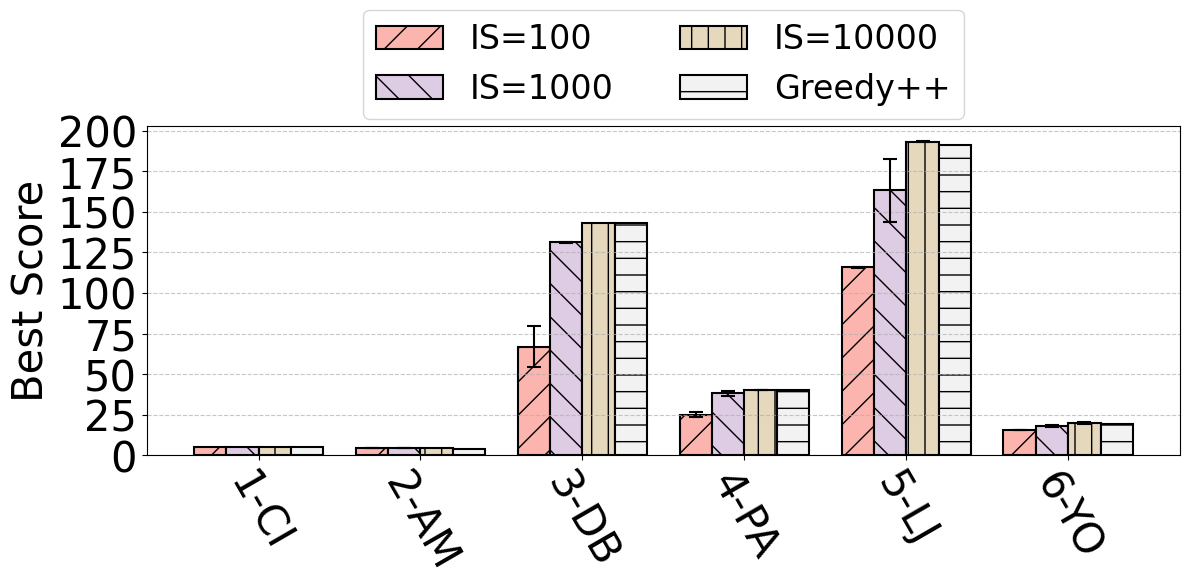

In [47]:
import math

# Setup variables
grouping_cols = ["graph_name"]
obj_function = ["densesubgraph"]
metaheuristic = ["vns"]

# Filter the Data
df = grouped_df[
    (grouped_df["metaheuristic"].isin(metaheuristic)) &
    (grouped_df["objective_function"].isin(obj_function)) &
    (grouped_df['graph_name'].isin(['citeseer', 'amazon', 'dblp', 'patents', 'livejournal', 'youtube'])) &
    (grouped_df['num_initial_solutions'] > 32)
    ].copy()

# Rename graphs
df['graph_name'] = df['graph_name'].replace({
    'citeseer': '1-CI',
    'amazon': '2-AM',
    'dblp': '3-DB',
    'patents': '4-PA',
    'livejournal': '5-LJ',
    'youtube': '6-YO',
})

# Create the Title
algo_name = metaheuristic[0].upper()
title = f"{algo_name} - Optimality Dense Subgraph"

# Plot graph
plot_average_by_group_and_initial_solutions(
    df,
    grouping_cols,
    metaheuristic,
    {'Greedy++': [4.905,3.758,143,40.129,190.984,19.389]},
    log_scale=False,
    figsize=(12,6)
)

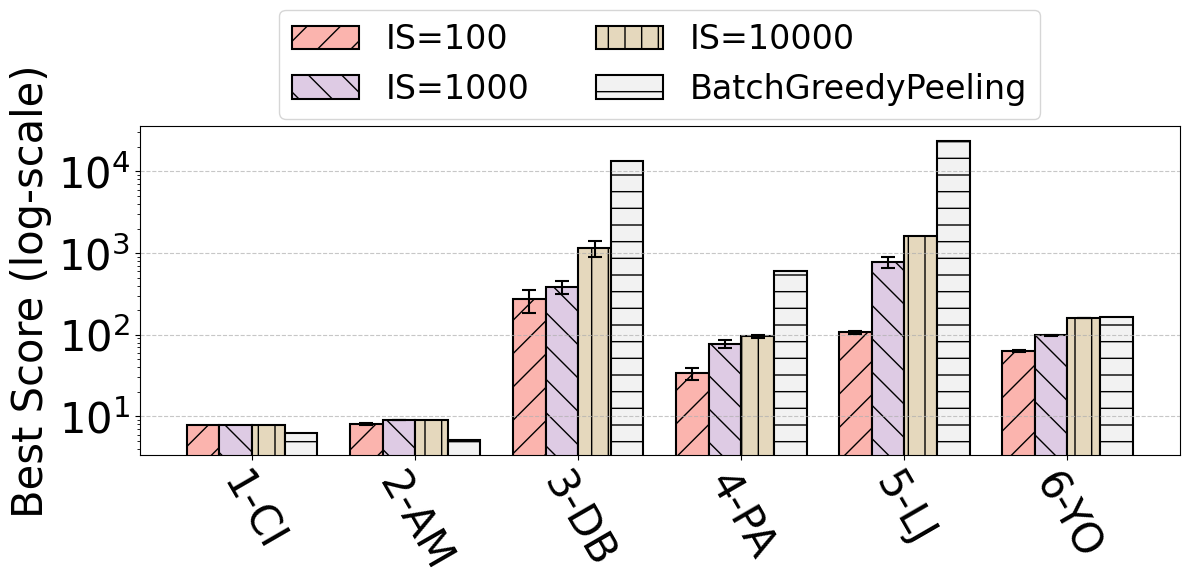

In [48]:
import math

# Setup variables
grouping_cols = ["graph_name"]
obj_function = ["triangledensestsubgraph"]
metaheuristic = ["vns"]

# Filter the Data
df = grouped_df[
    (grouped_df["metaheuristic"].isin(metaheuristic)) &
    (grouped_df["objective_function"].isin(obj_function)) &
    (grouped_df['graph_name'].isin(['citeseer', 'amazon', 'dblp', 'patents', 'livejournal', 'youtube'])) &
    (grouped_df['num_initial_solutions'] > 32)
    ].copy()

# Rename graphs
df['graph_name'] = df['graph_name'].replace({
    'citeseer': '1-CI',
    'amazon': '2-AM',
    'dblp': '3-DB',
    'patents': '4-PA',
    'livejournal': '5-LJ',
    'youtube': '6-YO',
})

# Create the Title
algo_name = metaheuristic[0].upper()
title = f"{algo_name} - Optimality Triangle Densest Subgraph"

# Plot graph
plot_average_by_group_and_initial_solutions(
    df,
    grouping_cols,
    metaheuristic,
    {'BatchGreedyPeeling': [6.272727273,5.094339623,13585,599.8496241,23870.01567,164.1794872]},
    log_scale=True,
    figsize=(12,6)
)

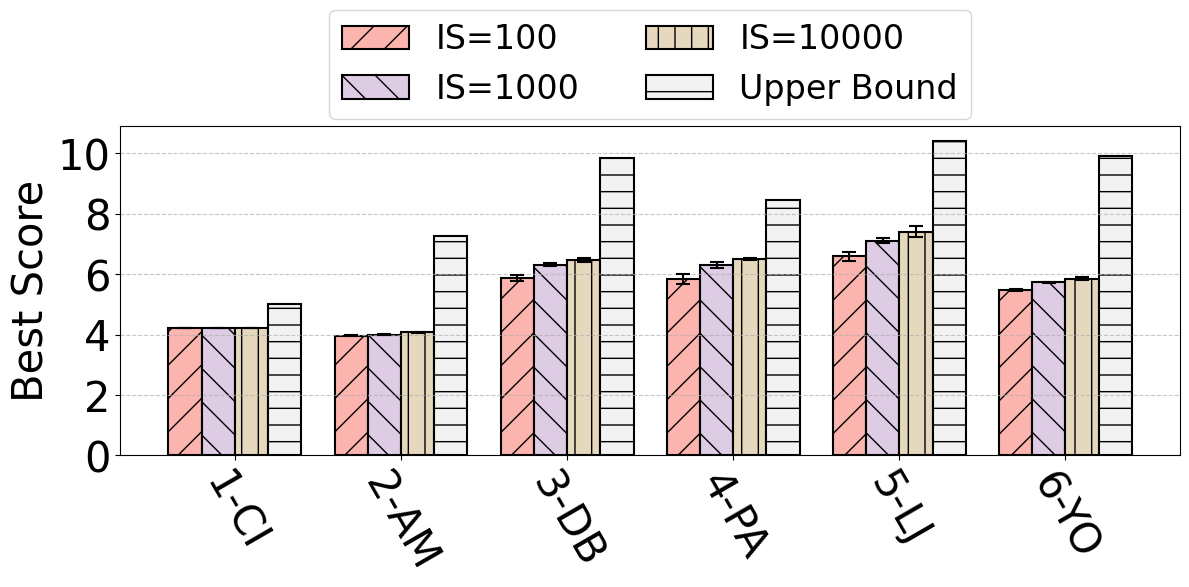

In [49]:
import math

# Setup variables
grouping_cols = ["graph_name"]
obj_function = ["degreeentropy"]
metaheuristic = ["vns"]

# Filter the Data
df = grouped_df[
    (grouped_df["metaheuristic"].isin(metaheuristic)) &
    (grouped_df["objective_function"].isin(obj_function)) &
    (grouped_df['graph_name'].isin(['citeseer', 'amazon', 'dblp', 'patents', 'livejournal', 'youtube'])) &
    (grouped_df['num_initial_solutions'] > 32)
    ].copy()

# Rename graphs
df['graph_name'] = df['graph_name'].replace({
    'citeseer': '1-CI',
    'amazon': '2-AM',
    'dblp': '3-DB',
    'patents': '4-PA',
    'livejournal': '5-LJ',
    'youtube': '6-YO',
})

# Create the Title
algo_name = metaheuristic[0].upper()
title = f"{algo_name} - Optimality Degree Entropy"

# Unique degrees following graph order
unique_degrees = [32, 153, 926, 351, 1355, 969]

# Calculate Degree Entropy
def upper_bound_entropy(n):
    e = 0
    for i in range(n):
        p = 1 / n
        e = e - p * math.log2(p)
    return e

# Plot graph
plot_average_by_group_and_initial_solutions(
    df,
    grouping_cols,
    metaheuristic,
    {'Upper Bound': [upper_bound_entropy(n) for n in unique_degrees]},
    log_scale=False,
    figsize=(12,6)
)

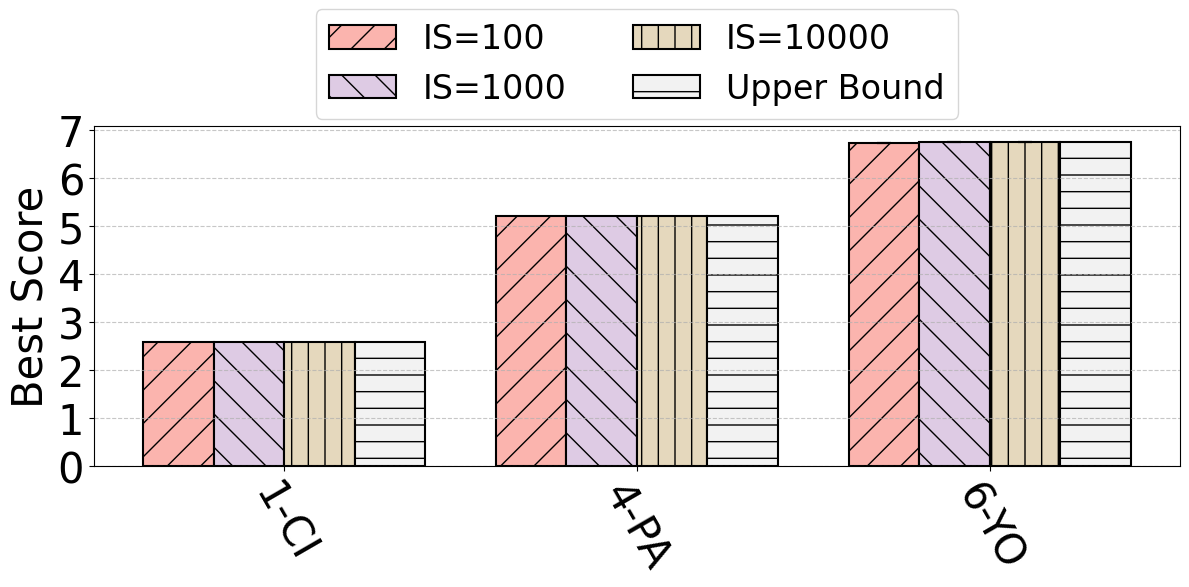

In [50]:
# Setup variables
grouping_cols = ["graph_name"]
obj_function = ["labelentropy"]
metaheuristic = ["vns"]

# Filter the Data
df = grouped_df[
    (grouped_df["metaheuristic"].isin(metaheuristic)) &
    (grouped_df["objective_function"].isin(obj_function)) &
    (grouped_df['graph_name'].isin(['citeseer', 'amazon', 'dblp', 'patents', 'livejournal', 'youtube'])) &
    (grouped_df['num_initial_solutions'] > 32)
    ].copy()

# Rename graphs
df['graph_name'] = df['graph_name'].replace({
    'citeseer': '1-CI',
    'amazon': '2-AM',
    'dblp': '3-DB',
    'patents': '4-PA',
    'livejournal': '5-LJ',
    'youtube': '6-YO',
})

# Create the Title
algo_name = metaheuristic[0].upper()
title = f"{algo_name} - Optimality Label Entropy"
    
# Unique degrees following graph order
unique_labels = [6, 37, 108]

# Calculate Label Entropy
def upper_bound_entropy(n):
    e = 0
    for i in range(n):
        p = 1 / n
        e = e - p * math.log2(p)
    return e

# Plot the graph
plot_average_by_group_and_initial_solutions(
    df,
    grouping_cols,
    metaheuristic,
    {'Upper Bound': [upper_bound_entropy(n) for n in unique_labels]},
    log_scale=False,
    figsize=(12,6)
)

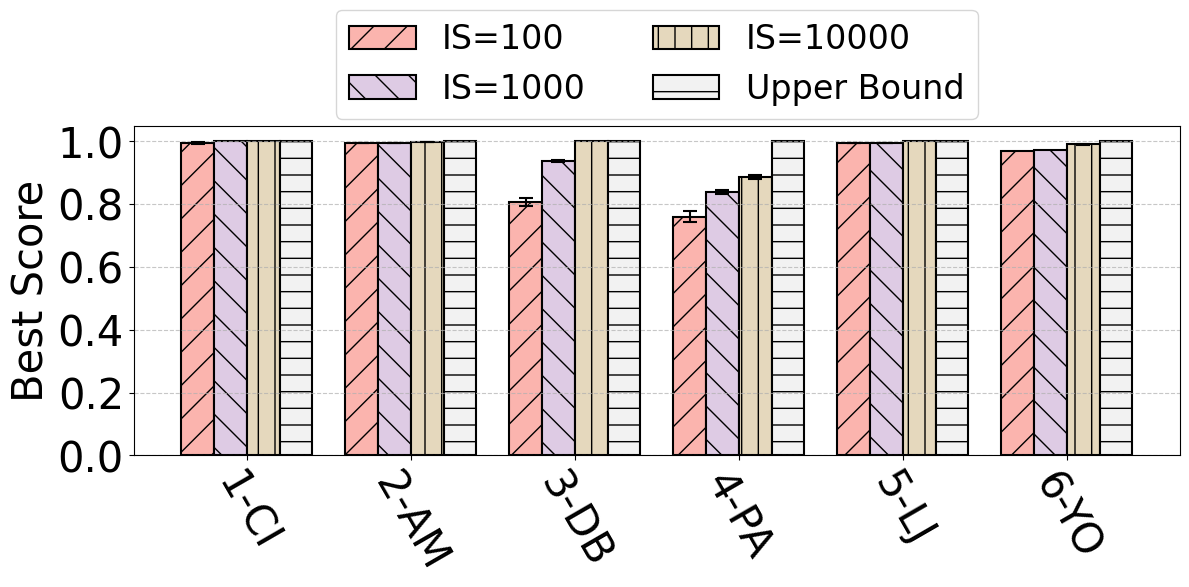

In [51]:
# Setup variables
grouping_cols = ["graph_name"]
obj_function = ["conductance"]
metaheuristic = ["vns"]

# Filter the Data
df = grouped_df[
    (grouped_df["metaheuristic"].isin(metaheuristic)) &
    (grouped_df["objective_function"].isin(obj_function)) &
    (grouped_df['graph_name'].isin(['citeseer', 'amazon', 'dblp', 'patents', 'livejournal', 'youtube'])) &
    (grouped_df['num_initial_solutions'] > 32)
    ].copy()

# Rename graphs
df['graph_name'] = df['graph_name'].replace({
    'citeseer': '1-CI',
    'amazon': '2-AM',
    'dblp': '3-DB',
    'patents': '4-PA',
    'livejournal': '5-LJ',
    'youtube': '6-YO',
})

# Create the Title
algo_name = metaheuristic[0].upper()
title = f"{algo_name} - Optimality Conductance"

# Plot graph
plot_average_by_group_and_initial_solutions(
    df,
    grouping_cols,
    metaheuristic,
    {'Upper Bound': [1,1,1,1,1,1]},
    log_scale=False,
    figsize=(12,6)
)